# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"C:\Dataset for practice\Label datasets\heart.csv")

# EDA(Exploratory Data Analysis)

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.shape

(918, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [6]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


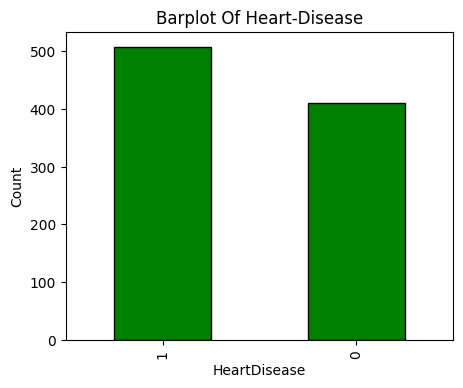

In [7]:
plt.figure(figsize=(5,4))
df['HeartDisease'].value_counts().plot(kind='bar', color='g', edgecolor='black')
plt.title('Barplot Of Heart-Disease')
plt.ylabel('Count')
plt.show()

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

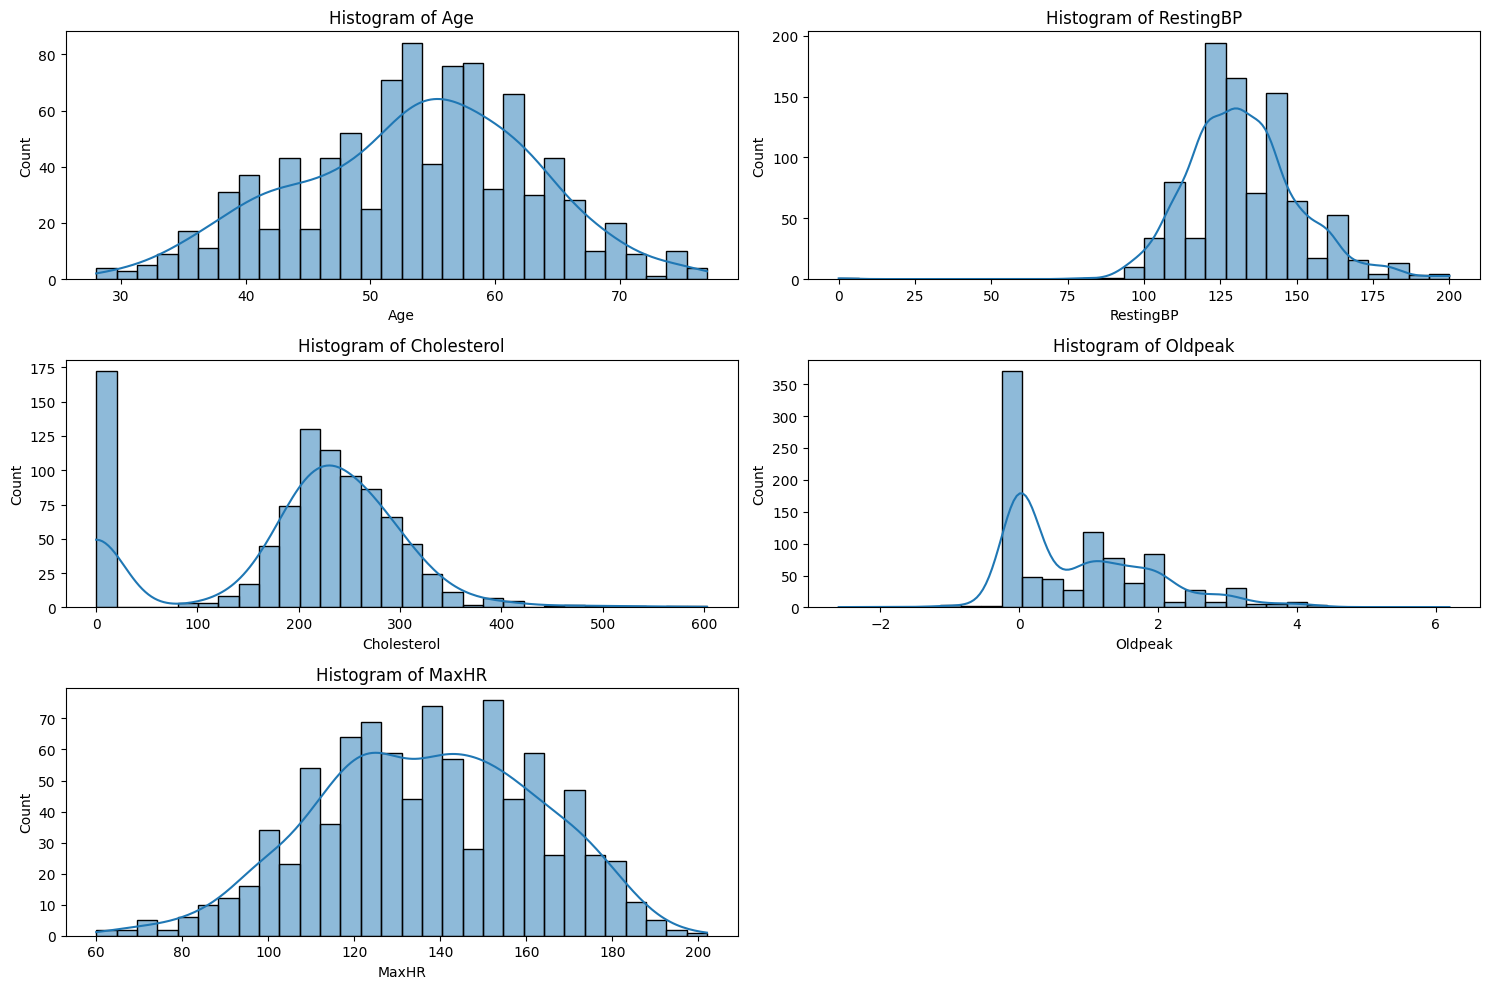

In [10]:
cols = df[['Age','RestingBP','Cholesterol','Oldpeak','MaxHR']]

plt.figure(figsize=(15,10))

for n ,col in enumerate(cols):
    plt.subplot(3,2, 1+n)
    sns.histplot(data=df[col], kde=True, bins=30)
    plt.title(f'Histogram of {col}')

plt.tight_layout()
plt.show()

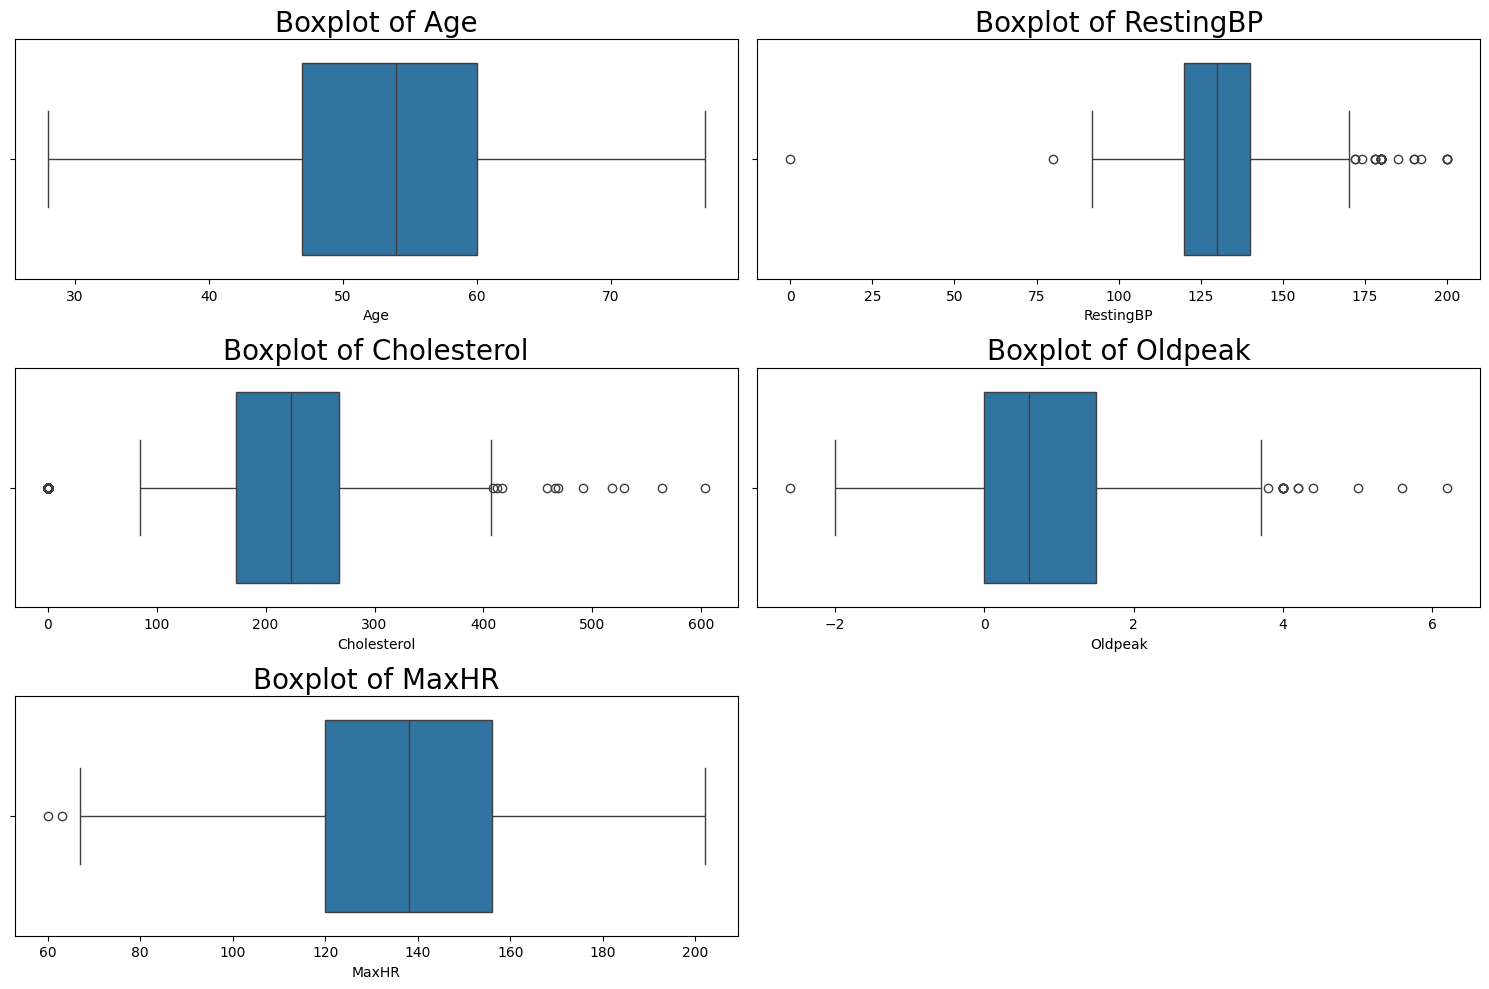

In [11]:
cols = df[['Age','RestingBP','Cholesterol','Oldpeak','MaxHR']]

plt.figure(figsize=(15,10))

for i, col in enumerate(cols):
    plt.subplot(3,2, 1+i)
    sns.boxplot(data = df, x = col)
    plt.title(f'Boxplot of {col}', fontsize=20)

plt.tight_layout()
plt.show()

# 🧹Cleaning Data

In [12]:
cho_mean = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].mean().round(2)

df['Cholesterol'] = df['Cholesterol'].replace(0, cho_mean)
df['RestingBP'] = df['RestingBP'].replace(0, df['RestingBP'].median())

In [13]:
df['RestingBP'].mean(),df['RestingBP'].median()

(np.float64(132.53812636165577), np.float64(130.0))

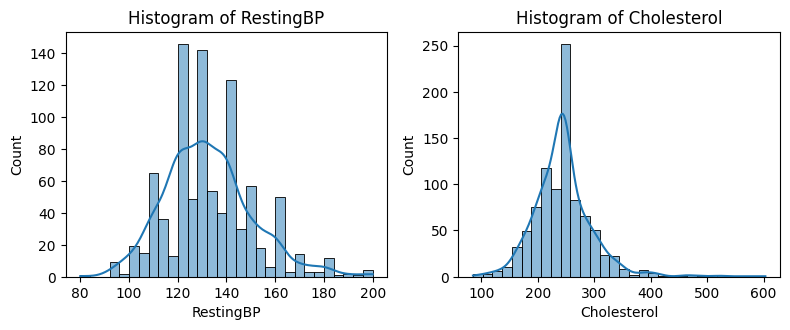

In [14]:
cols = df[['RestingBP','Cholesterol']]

plt.figure(figsize=(8,6))

for n ,col in enumerate(cols):
    plt.subplot(2,2, 1+n)
    sns.histplot(data=df[col], kde=True, bins=30)
    plt.title(f'Histogram of {col}')

plt.tight_layout()
plt.show()

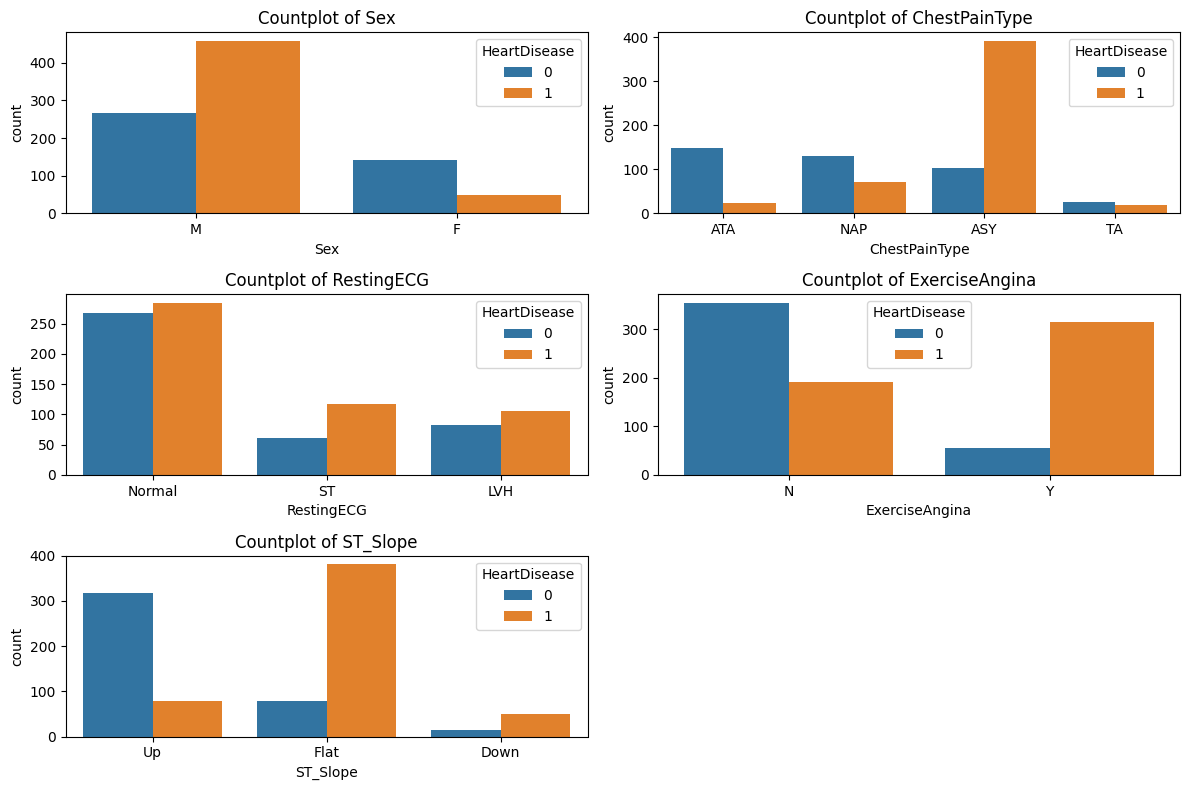

In [15]:
cols = df[['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope']]
x = df['HeartDisease']

plt.figure(figsize=(12,8))

for n ,col in enumerate(cols):
    plt.subplot(3,2, 1+n)
    sns.countplot(x=df[col], hue=x)
    plt.title(f'Countplot of {col}')

plt.tight_layout()
plt.show()

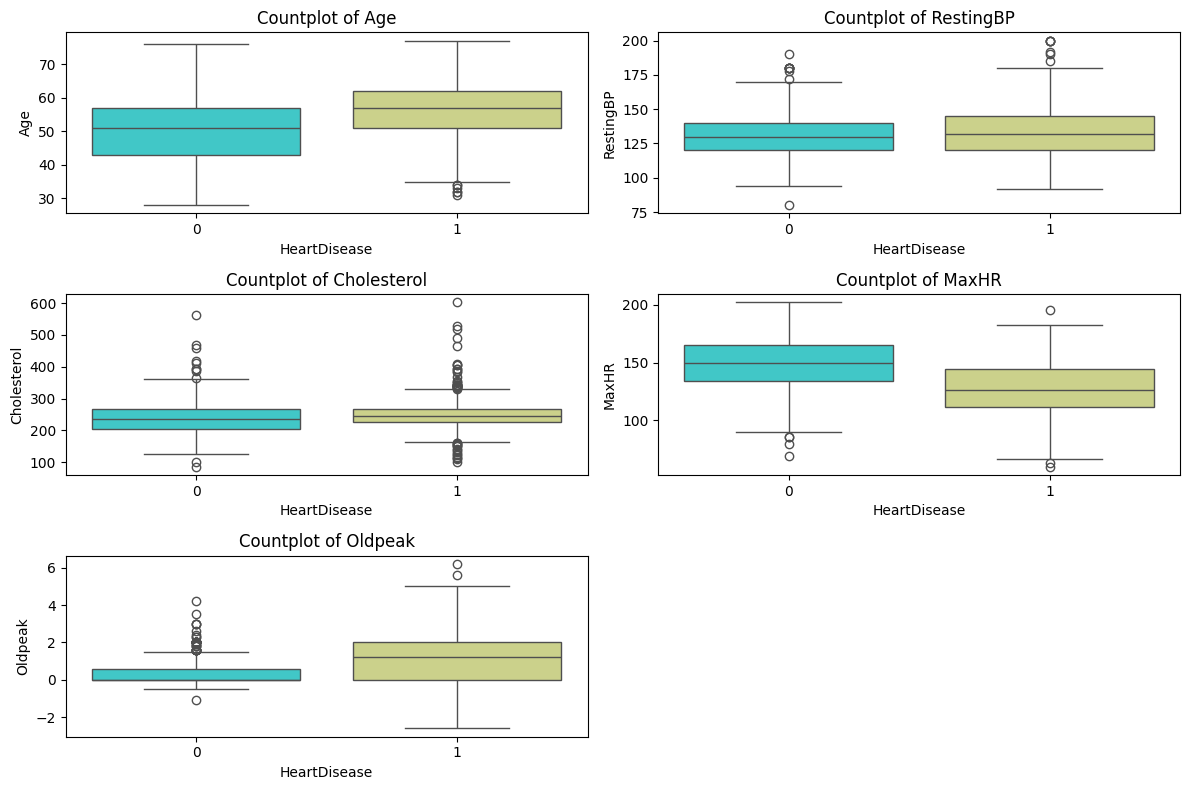

In [16]:
cols = df[['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']]
x = df['HeartDisease']

plt.figure(figsize=(12,8))

for n ,col in enumerate(cols):
    plt.subplot(3,2, 1+n)
    sns.boxplot(x= x, y= df[col], palette='rainbow')
    plt.title(f'Countplot of {col}')

plt.tight_layout()
plt.show()

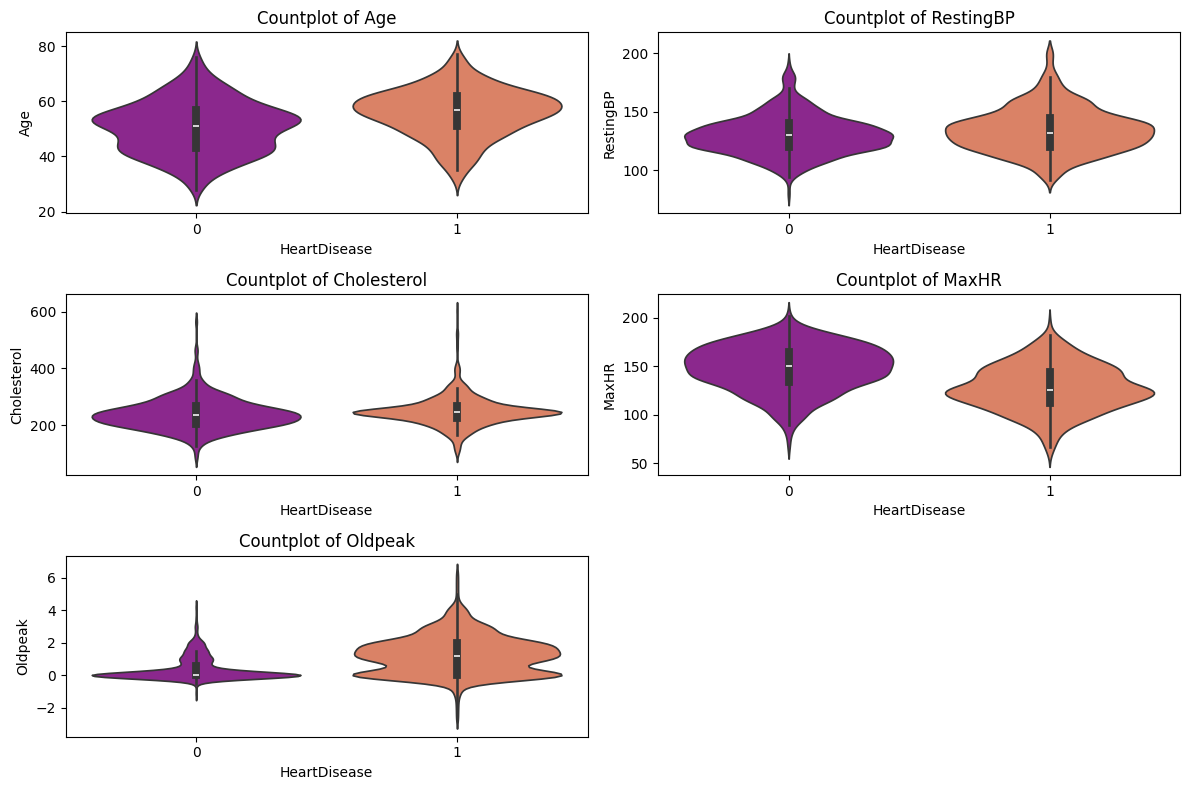

In [17]:
cols = df[['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']]
x = df['HeartDisease']

plt.figure(figsize=(12,8))

for n ,col in enumerate(cols):
    plt.subplot(3,2, 1+n)
    sns.violinplot(x= x, y= df[col], palette='plasma')
    plt.title(f'Countplot of {col}')

plt.tight_layout()
plt.show()

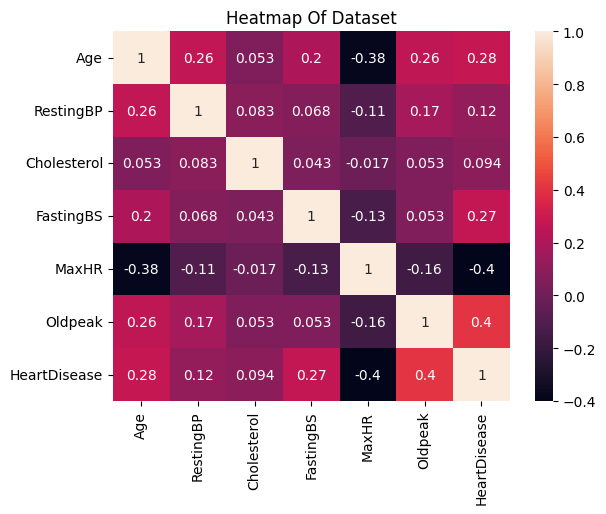

In [18]:
corr = df.select_dtypes(include='number').corr()

sns.heatmap(data = corr, annot=True)
plt.title('Heatmap Of Dataset')
plt.show()

# Data Preprocessing

In [19]:
df_encoded = pd.get_dummies(df, drop_first=True).astype(int)

df_encoded.head(2)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0


In [20]:
x = df_encoded.drop('HeartDisease', axis=1)
y = df['HeartDisease']

In [21]:
model = RandomForestClassifier(random_state=42)
model.fit(x,y)

importance = model.feature_importances_.round(2)*100

for col,imp in zip(x.columns, importance):
    print(f"{col}: {imp}%")

Age: 9.0%
RestingBP: 8.0%
Cholesterol: 9.0%
FastingBS: 3.0%
MaxHR: 13.0%
Oldpeak: 7.000000000000001%
Sex_M: 4.0%
ChestPainType_ATA: 4.0%
ChestPainType_NAP: 3.0%
ChestPainType_TA: 1.0%
RestingECG_Normal: 2.0%
RestingECG_ST: 1.0%
ExerciseAngina_Y: 9.0%
ST_Slope_Flat: 10.0%
ST_Slope_Up: 17.0%


In [22]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [23]:
Scaler = StandardScaler()

x_train_ss = Scaler.fit_transform(x_train)
x_test_ss = Scaler.transform(x_test)

# Selecting Model

In [24]:
models = {
    'Logistic Regression':LogisticRegression(),
    'Decision Tree':DecisionTreeClassifier(),
    'KNN':KNeighborsClassifier(),
    'SVM':SVC(),
    'Random Forest':RandomForestClassifier(),
    'XGBOOST':XGBClassifier()
}

for name,model in models.items():
    model.fit(x_train_ss, y_train)
    print(f'--------------{name}------------')
    print(classification_report(y_test, model.predict(x_test_ss)))
    print('Confusion Matrix:',confusion_matrix(y_test, model.predict(x_test_ss)))
    print('-'*50)

--------------Logistic Regression------------
              precision    recall  f1-score   support

           0       0.82      0.88      0.85        77
           1       0.91      0.86      0.88       107

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184

Confusion Matrix: [[68  9]
 [15 92]]
--------------------------------------------------
--------------Decision Tree------------
              precision    recall  f1-score   support

           0       0.72      0.81      0.76        77
           1       0.85      0.78      0.81       107

    accuracy                           0.79       184
   macro avg       0.78      0.79      0.79       184
weighted avg       0.79      0.79      0.79       184

Confusion Matrix: [[62 15]
 [24 83]]
--------------------------------------------------
--------------KNN------------
              precision    recall  f1-score   support


In [25]:
model = LogisticRegression()
model.fit(x_train_ss, y_train)

model.score(x_test_ss, y_test), model.score(x_train_ss, y_train),

(0.8695652173913043, 0.8664850136239782)

# Saving The Model

In [26]:
joblib.dump(model, 'HeartDisease.pkl')
joblib.dump(Scaler, 'Scaler.pkl')
joblib.dump(x.columns.tolist(), 'Columns.pkl')

['Columns.pkl']